# Log-Based Web Attack Classification

# 1. Setup & Download Dataset

In [3]:
import os, sys, gzip, glob, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
np.random.seed(42)  # global seed for reproducibility

# download organization-x (2 MB)
#!wget -q -O organization-x.zip "https://zenodo.org/api/records/20001206/files/organization-x.zip/content"
!unzip -q -o /content/organization-x.zip

BASE = "organization-x"
print("Extracted contents:")
for root, dirs, files in os.walk(BASE):
    print(root, "->", len(files), "files")


Extracted contents:
organization-x -> 0 files
organization-x/log -> 13 files
organization-x/log/apache2 -> 32 files
organization-x/ground-truth -> 1 files


In [4]:
# Inspect what is inside
import os
print("\nTop-level files:")
for f in sorted(os.listdir(BASE)):
    print("  ", f)

print("\nGround truth file:")
print("  ", os.path.join(BASE, "ground-truth", "organization-x.yaml"))

print("\nApache log files:")
for f in sorted(os.listdir(os.path.join(BASE, "log", "apache2")))[:40]:
    print("  ", f)



Top-level files:
   ground-truth
   log

Ground truth file:
   organization-x/ground-truth/organization-x.yaml

Apache log files:
   error.log
   error.log.1
   error.log.10.gz
   error.log.11.gz
   error.log.12.gz
   error.log.13.gz
   error.log.14.gz
   error.log.2.gz
   error.log.3.gz
   error.log.4.gz
   error.log.5.gz
   error.log.6.gz
   error.log.7.gz
   error.log.8.gz
   error.log.9.gz
   other_vhosts_access.log
   web-access.log
   web-error.log
   web-error.log.1
   web-error.log.10.gz
   web-error.log.11.gz
   web-error.log.12.gz
   web-error.log.13.gz
   web-error.log.14.gz
   web-error.log.2.gz
   web-error.log.3.gz
   web-error.log.4.gz
   web-error.log.5.gz
   web-error.log.6.gz
   web-error.log.7.gz
   web-error.log.8.gz
   web-error.log.9.gz


# 2. Understand the Data

In [5]:
# Read the ground-truth labelling rules
YAML_PATH = os.path.join(BASE, "ground-truth", "organization-x.yaml")

with open(YAML_PATH, encoding="utf-8") as f:
    rules = yaml.safe_load(f)

print("Number of rules:", len(rules))
for r in rules:
    print(f"- {r['id']:28s} -> {r['ground_truth_label']:30s} [{r['sensitivity']}] {r['filter']}")

for r in rules:
    if r["ground_truth_label"] == "sql_injection_attempt":
        if r["filter"] == ["SELECT%"]:
            r["pats_override"] = ["select ", " from "]
        elif r["filter"] == ["UNION%"]:
            r["pats_override"] = ["union ", " select "]
        elif r["filter"] == ["UNION+"]:
            r["pats_override"] = ["union+", " select+"]
print("\nTightened SELECT/UNION SQLi rules to require both keywords (avoids select2 FP).")


Number of rules: 39
- dir_scan                     -> dir_scan                       [moderate] ['code: 404', 'Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0)']
- dir_scan                     -> dir_scan_go                    [moderate] ['Go-http-client']
- dir_scan                     -> dir_scan_python                [moderate] ['code: 302', 'python']
- dir_scan                     -> dir_scan                       [strict] ['%Mozilla/5.0 (Windows NT 10.0; Win64; x64)', '%POST%', '%400%']
- dir_scan                     -> dir_scan                       [strict] ['%Mozilla/5.0 (Windows NT 10.0; Win64; x64)', '%GET%', '%302%']
- path_traversal               -> path_traversal                 [moderate] ['readme.txt', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)']
- rce_shell                    -> rce_shell                      [moderate] ['POST', 'python']
- rce_shell                    -> rce_shell                      [moderate] ['HEAD', 'python']
- rce_shell            

In [6]:
# Peek at the raw log files (access log, auth log, syslog)
def head_file(path, n=8):
    print(f"\n===== {path} =====")
    if path.endswith(".gz"):
        import gzip
        txt = gzip.open(path, "rt", encoding="utf-8", errors="replace").read()
    else:
        txt = open(path, encoding="utf-8", errors="replace").read()
    for line in txt.splitlines()[:n]:
        print(line)

head_file(os.path.join(BASE, "log", "apache2", "web-access.log"))
head_file(os.path.join(BASE, "log", "apache2", "web-error.log"))
head_file(os.path.join(BASE, "log", "auth.log"))
head_file(os.path.join(BASE, "log", "syslog"))



===== organization-x/log/apache2/web-access.log =====
104.248.1.48 - - [07/Oct/2025:19:47:10 +0700] "GET /login?redirect=javascript:alert(1) HTTP/1.0" 200 2512 "http://sub1.domain1.com/" "python-requests/2.25.1"
198.51.100.53 - - [07/Oct/2025:18:49:56 +0700] "GET /js/main.js HTTP/1.0" 200 1500 "-" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/217.155.106.155 Safari/537.36 Edg/217.155.106.155"
203.0.113.58 - - [07/Oct/2025:02:27:54 +0700] "POST /api/comments HTTP/1.0" 200 5710 "https://sub1.domain1.com/products" "Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) SamsungBrowser/28.0 Chrome/57.155.29.120 Mobile Safari/537.36"
203.0.113.41 - - [07/Oct/2025:15:46:13 +0700] "GET /help HTTP/1.0" 200 7000 "https://sub1.domain1.com/1.php" "Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/239.155.32.137 Mobile Safari/537.36"
10.0.0.37 - - [07/Oct/2025:22:43:25 +0700] "GET /blog/post-3 HTTP/1.0" 20

# 3. Parse Logs into a Table

In [7]:
# Define the access-log parser
# Uses non-greedy `"(.*?)"` so attack payloads containing literal `"` in URLs

ACCESS_RE = re.compile(
    r'^(\S+) (\S+) (\S+) \[([^\]]+)\] "(.*?)" (\d{3}) (\S+) "(.*?)" "(.*?)"\s*$'
)

def read_maybe_gz(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
            return f.read()
    with open(path, encoding="utf-8", errors="replace") as f:
        return f.read()

def parse_access_logs(log_dir):
    rows = []
    unparseable = []
    files = sorted(glob.glob(os.path.join(log_dir, "web-access.log*")))
    for path in files:
        for line_no, line in enumerate(read_maybe_gz(path).splitlines(), 1):
            line = line.strip()
            if not line:
                continue
            m = ACCESS_RE.match(line)
            if not m:
                unparseable.append((os.path.basename(path), line_no, line[:200]))
                continue
            ip, _, _, ts, request, status, size, referer, ua = m.groups()
            parts = request.split(" ", 2)
            method = parts[0]
            url = parts[1] if len(parts) > 1 else ""
            rows.append((ip, ts, method, url, int(status), size, referer, ua, line))
    df = pd.DataFrame(rows, columns=["ip","ts","method","url","status","size","referer","ua","raw"])
    return df, unparseable

t0 = time.time()
df, unparseable = parse_access_logs(os.path.join(BASE, "log", "apache2"))
print(f"Parsed {len(df):,} access-log entries in {time.time()-t0:.1f}s")
print(f"Unparseable lines: {len(unparseable)} (expected: 0)")
if unparseable:
    print("Sample unparseable lines (first 5):")
    for f, n, l in unparseable[:5]:
        print(f"  [{f}:{n}] {l}")
df.head()


Parsed 5,000 access-log entries in 0.1s
Unparseable lines: 0 (expected: 0)


,ip,ts,method,url,status,size,referer,ua,raw
0,104.248.1.48,07/Oct/2025:19:47:10 +0700,GET,/login?redirect=javascript:alert(1),200,2512,http://sub1.domain1.com/,python-requests/2.25.1,104.248.1.48 - - [07/Oct/2025:19:47:10 +0700] ...
1,198.51.100.53,07/Oct/2025:18:49:56 +0700,GET,/js/main.js,200,1500,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,198.51.100.53 - - [07/Oct/2025:18:49:56 +0700]...
2,203.0.113.58,07/Oct/2025:02:27:54 +0700,POST,/api/comments,200,5710,https://sub1.domain1.com/products,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,203.0.113.58 - - [07/Oct/2025:02:27:54 +0700] ...
3,203.0.113.41,07/Oct/2025:15:46:13 +0700,GET,/help,200,7000,https://sub1.domain1.com/1.php,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,203.0.113.41 - - [07/Oct/2025:15:46:13 +0700] ...
4,10.0.0.37,07/Oct/2025:22:43:25 +0700,GET,/blog/post-3,200,3500,https://sub1.domain1.com/1.php,Mozilla/5.0 (X11; Linux x86_64; rv:143.0) Geck...,"10.0.0.37 - - [07/Oct/2025:22:43:25 +0700] ""GE..."


# 3.2 Data dictionary

# 3b. Data Quality Check

In [8]:
# Inspect shape, types and missing values
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nMissing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(3))
print("\nRows with size == '-':", (df["size"] == "-").sum())
print("Rows with empty url:", (df["url"].str.strip() == "").sum())


Shape: (5000, 9)

Column types:
ip         object
ts         object
method     object
url        object
status      int64
size       object
referer    object
ua         object
raw        object
dtype: object

Missing values per column:
ip         0
ts         0
method     0
url        0
status     0
size       0
referer    0
ua         0
raw        0
dtype: int64

Missing value percentage:
ip         0.0
ts         0.0
method     0.0
url        0.0
status     0.0
size       0.0
referer    0.0
ua         0.0
raw        0.0
dtype: float64

Rows with size == '-': 0
Rows with empty url: 0


In [9]:
# Duplicate rows
print("Exact duplicate rows:", df.duplicated().sum())
dup_cols = ["ip", "method", "url", "status", "size", "referer", "ua"]
print("Repeated requests (same request, different timestamp):", df.duplicated(subset=dup_cols).sum())

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df):,} exact duplicates -> {len(df):,} rows remain")


Exact duplicate rows: 0
Repeated requests (same request, different timestamp): 1
Removed 0 exact duplicates -> 5,000 rows remain


In [10]:
# Summary statistics (numeric columns)
df.describe()


,status
count,5000.000000
mean,289.823600
std,91.545509
min,200.000000
25%,200.000000
50%,302.000000
75%,400.000000
max,500.000000


# 4. Label Entries (Ground Truth)

In [11]:
# Normalize rules and apply them (double-decode + whitelist + extended signatures)
from urllib.parse import unquote_plus, unquote

rules = [r for r in rules if not (
    r["ground_truth_label"] == "dir_scan"
    and r["sensitivity"] == "strict"
    and any("Windows NT 10.0" in p for p in r["filter"])
    and any("302" in p for p in r["filter"])
)]

for r in rules:
    if "pats_override" in r:
        r["pats"] = r["pats_override"]
    else:
        r["pats"] = [p.replace("%", "").lower() for p in r["filter"]]

# Legitimate monitoring / search bots -> always benign
WHITELIST_UA = re.compile(
    r"(HetrixTools|Uptime-Kuma|internal dummy connection|NetworkingExtension|"
    r"Googlebot|Bingbot|facebookexternalhit|Twitterbot|AppleBot|LinkedInBot|"
    r"WhatsApp|TelegramBot|Discordbot|DuckDuckBot|YandexBot|Baiduspider)",
    re.IGNORECASE)

EXTRA_RULES = [
    ("sql_injection_attempt", ["or true", "and false", "or 1=1", "1=1--", "'--", ";--",
                                "extractvalue(", "updatexml(", "union select", "union+select",
                                "information_schema", "sleep(", "benchmark("]),
    ("cross_site_scripting",  ["<script", "onerror=", "onload=", "javascript:", "alert(",
                                "<svg", "document.cookie", "<img src="]),
    ("path_traversal",        ["../", "..\\", "%2e%2e", "/etc/passwd", "/etc/shadow",
                                "php://filter", "php://input", "/proc/self/",
                                "expect://", "win.ini", "boot.ini"]),
    ("remote_code",           [";cat ", ";ls ", ";wget", ";curl", "whoami", "/bin/sh",
                                "base64_decode(", "eval(", "system(", "shell_exec(",
                                "passthru(", "assert(", "processbuilder", "runtime.getruntime",
                                "redirectaction:", "ognlcontext"]),
    ("rce_shell",             ["/c99.php", "/r57.php", "/wso.php", "/b374k", "/weevely",
                                "/shell.php", "/webshell", "/backdoor"]),
    ("rce_shell",             ["${jndi:ldap:", "${jndi:dns:", "${jndi:rmi:"]),
]


SENSITIVE_PATHS = ["/phpinfo", "/phpmyadmin", "/wp-admin", "/xmlrpc.php",
                  "/cgi-bin/", "/actuator", "/solr/", "/jenkins", "/.env",
                  "/.git/", "/.svn/", "/admin.php"]

def label_line(raw, status, ua):
    # Whitelist short-circuit: known-good monitoring bots are never attacks
    if WHITELIST_UA.search(ua):
        return "benign"
    once  = unquote_plus(raw).lower()
    twice = unquote(once).lower()
    text  = once + " " + twice + f" code: {status}"
    for r in rules:
        if all(p in text for p in r["pats"]):
            return r["ground_truth_label"]
    for label, pats in EXTRA_RULES:
        if all(p in text for p in pats):
            return label
    for p in SENSITIVE_PATHS:
        if p in text:
            return "dir_scan"
    return "benign"

df["label"] = [label_line(r, s, u) for r, s, u in zip(df["raw"], df["status"], df["ua"])]
df["is_attack"] = (df["label"] != "benign").astype(int)


In [12]:
# Check the class distribution + labelling audit
print("Label distribution:")
print(df["label"].value_counts())
print("\nAttack ratio: {:.2f}%".format(100 * df["is_attack"].mean()))

print("\n" + "="*78)
print("  LABELLING AUDIT (for transparency)")
print("="*78)
print(f"  Total rows after dedup        : {len(df):,}")
print(f"  Flagged as attack              : {df['is_attack'].sum():,}")
print(f"  Flagged as benign              : {(df['is_attack']==0).sum():,}")
print(f"  Attack ratio                   : {100*df['is_attack'].mean():.3f}%")
print()


Label distribution:
label
benign                   3940
rce_read_file             183
dir_scan_go               171
dir_scan                  170
remote_code               154
dir_scan_python           151
sql_injection_attempt     129
rce_java                   64
cross_site_scripting       30
rce_shell                   8
Name: count, dtype: int64

Attack ratio: 21.20%

  LABELLING AUDIT (for transparency)
  Total rows after dedup        : 5,000
  Flagged as attack              : 1,060
  Flagged as benign              : 3,940
  Attack ratio                   : 21.200%



In [13]:
# Persist labelled dataset to CSV (for reproducibility)
out_path = "web_access_labelled.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} labelled rows to {out_path}")
print(f"File size: {os.path.getsize(out_path)/1024/1024:.1f} MB")


Saved 5,000 labelled rows to web_access_labelled.csv
File size: 2.0 MB


# 5. Exploratory Data Analysis (Visualization)

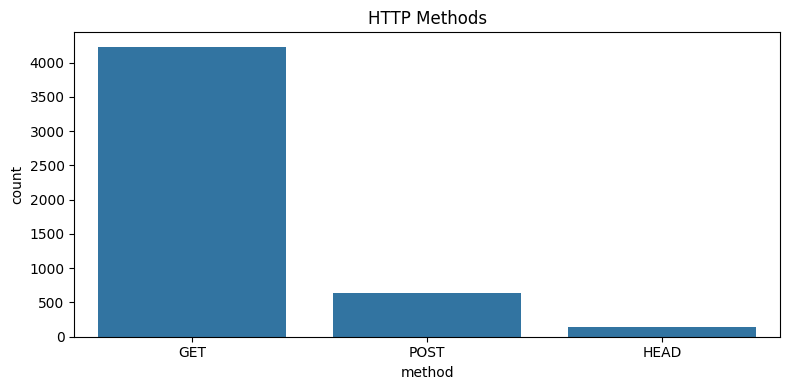

In [14]:
# HTTP method distribution
plt.figure(figsize=(8,4))
sns.countplot(x="method", data=df, order=df["method"].value_counts().index)
plt.title("HTTP Methods"); plt.tight_layout(); plt.show()


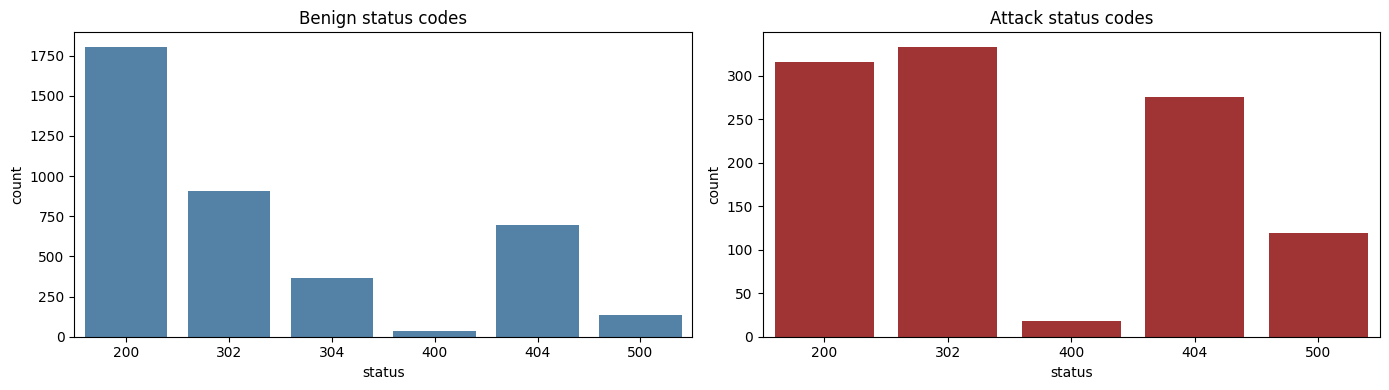

In [15]:
# Status code distribution (normal vs attack)
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.countplot(x="status", data=df[df.is_attack==0], ax=ax[0], color="steelblue")
ax[0].set_title("Benign status codes")
sns.countplot(x="status", data=df[df.is_attack==1], ax=ax[1], color="firebrick")
ax[1].set_title("Attack status codes")
plt.tight_layout(); plt.show()


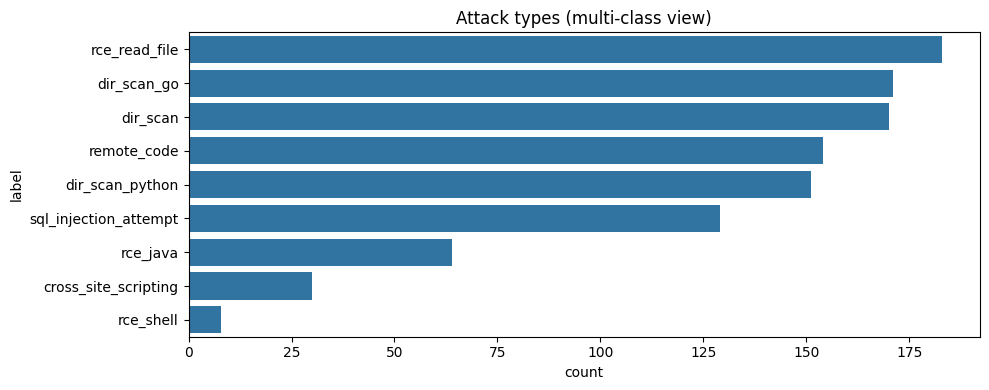

In [16]:
# Attack type distribution
att = df[df.is_attack==1]
plt.figure(figsize=(10,4))
sns.countplot(y="label", data=att, order=att["label"].value_counts().index)
plt.title("Attack types (multi-class view)")
plt.tight_layout(); plt.show()


# 6. Feature Engineering

In [17]:
# Compute engineered features (vectorized)
low  = df["url"].str.lower()
split = df["url"].str.split("?", n=1)
path  = split.str[0].fillna("")
query = split.str[1].fillna("")

feats = pd.DataFrame({
    "method":  df["method"],
    "status":  df["status"],
    "size":    pd.to_numeric(df["size"], errors="coerce").fillna(0).astype(int),
    "url_len":   df["url"].str.len(),
    "path_len":  path.str.len(),
    "query_len": query.str.len(),
    "n_params":  (query.str.count("&") + (query != "")).astype(int),
    "n_special": df["url"].str.count(r"[%'\"<>;\\|(){}\[\] ]"),
    "has_query": (df["url"].str.contains(r"\?")).astype(int),
    "n_dots":    df["url"].str.count(r"\."),
    "n_slashes": df["url"].str.count("/"),
})

SUSPICIOUS = ["select","union","sleep","concat","alert","<script","document.","../","etc/passwd",
              "cmd=","command=","base64","eval(","system(","ipconfig",".sh","cgi-bin",
              "=http://","=https://","<?php","<?=","runtime","/proc/self","passwd"]
for s in SUSPICIOUS:
    col = "kw_" + s.replace("=","_").replace(".","_").replace("/","_").replace("<","_").replace(">","_").replace("?","_")
    feats[col] = low.str.contains(s, regex=False).astype(int)

feats["label"]    = df["label"].values
feats["is_attack"] = df["is_attack"].values
feats["url"]      = df["url"].values

print("Feature table shape:", feats.shape)
feats.head()


Feature table shape: (5000, 37)


,method,status,size,url_len,path_len,query_len,n_params,n_special,has_query,n_dots,...,kw_cgi-bin,kw__http:__,kw__https:__,kw___php,kw_runtime,kw__proc_self,kw_passwd,label,is_attack,url
0,GET,200,2512,35,6,28,1,2,1,0,...,0,0,0,0,0,0,0,benign,0,/login?redirect=javascript:alert(1)
1,GET,200,1500,11,11,0,0,0,0,1,...,0,0,0,0,0,0,0,benign,0,/js/main.js
2,POST,200,5710,13,13,0,0,0,0,0,...,0,0,0,0,0,0,0,benign,0,/api/comments
3,GET,200,7000,5,5,0,0,0,0,0,...,0,0,0,0,0,0,0,benign,0,/help
4,GET,200,3500,12,12,0,0,0,0,0,...,0,0,0,0,0,0,0,benign,0,/blog/post-3


# 7. Descriptive Mining — K-Means Clustering

Clustering on 5,000 rows x 32 features
k=2: inertia=90072, silhouette=0.575
k=3: inertia=78537, silhouette=0.345
k=4: inertia=67784, silhouette=0.365
k=5: inertia=59409, silhouette=0.382
k=6: inertia=51844, silhouette=0.393
k=7: inertia=46882, silhouette=0.424
k=8: inertia=42695, silhouette=0.405
k=9: inertia=36866, silhouette=0.436
k=10: inertia=33199, silhouette=0.432


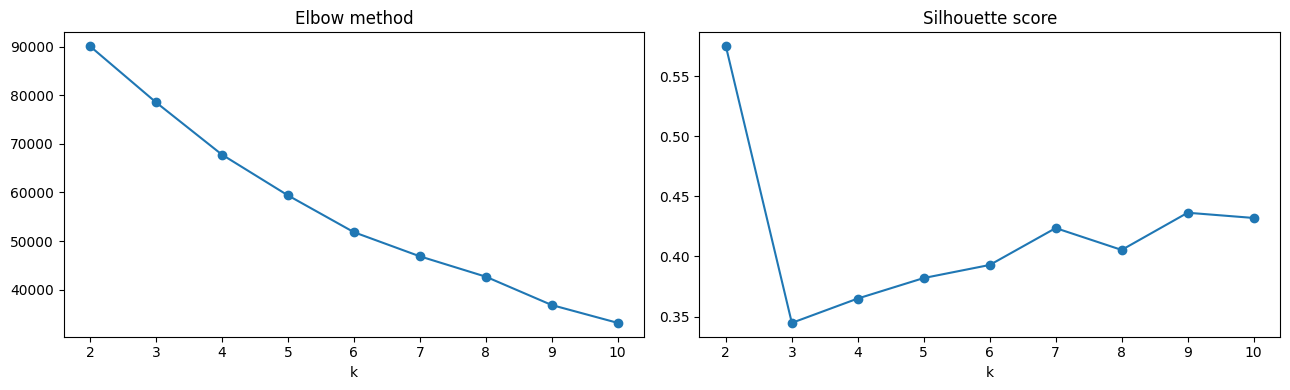

In [18]:
# K-Means: compute inertia + silhouette for k=2..10
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

num_cols = [c for c in feats.columns if c not in ("method","label","is_attack","url","status")]

_sample_n = min(20000, len(feats))
X_clust = StandardScaler().fit_transform(
    feats[num_cols].dropna().sample(_sample_n, random_state=42)
)
print(f"Clustering on {X_clust.shape[0]:,} rows x {X_clust.shape[1]} features")

inertia, sil = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_clust, km.labels_))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(list(K_range), inertia, marker="o"); ax[0].set_title("Elbow method"); ax[0].set_xlabel("k")
ax[1].plot(list(K_range), sil, marker="o");  ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()


## 7.1 Best-K Selection — Combined Elbow + Silhouette Visualization

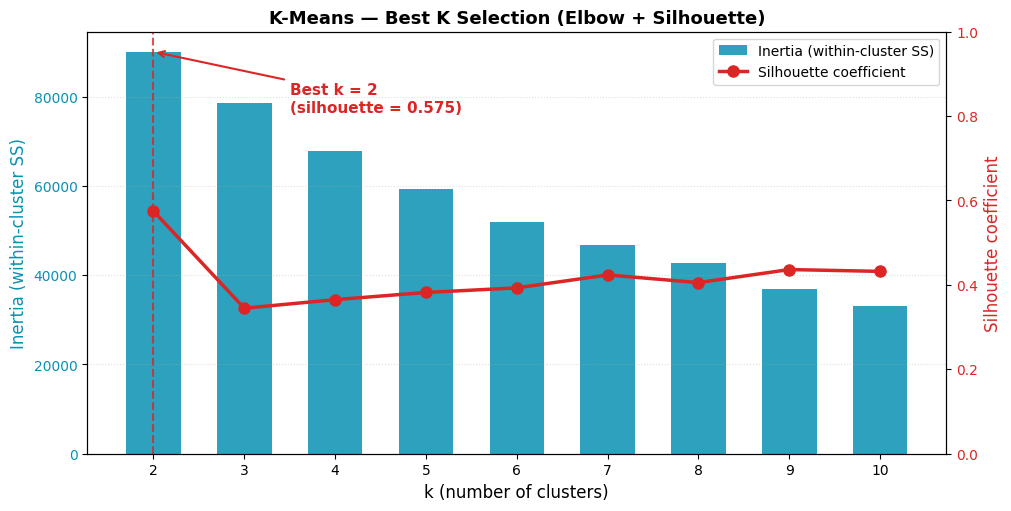


K-Means clustering metrics (k = 2 to 10), ranked by silhouette:
 k      inertia  silhouette  rank
 2 90072.272340    0.574869     1
 9 36865.675273    0.436371     2
10 33198.566992    0.432030     3
 7 46881.871194    0.423613     4
 8 42695.119169    0.405436     5
 6 51844.466030    0.392949     6
 5 59409.346883    0.382085     7
 4 67784.364344    0.365046     8
 3 78536.716742    0.344784     9

Best k = 2 (silhouette = 0.575).
The silhouette coefficient peaks at k = 2, confirming the binary
benign-vs-attack structure of the feature space. K-Means alone is
not a reliable attack detector — supervised classifiers in the next
section are the main contribution.


In [19]:
try:
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
    fm.fontManager.addfont('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
    plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

kmeans_df = pd.DataFrame({
    "k":          list(K_range),
    "inertia":    inertia,
    "silhouette": sil,
})
kmeans_df["rank"] = kmeans_df["silhouette"].rank(ascending=False).astype(int)

# Best k = the one with the highest silhouette coefficient
best_k   = int(kmeans_df.loc[kmeans_df["silhouette"].idxmax(), "k"])
best_sil = float(kmeans_df["silhouette"].max())

fig, ax1 = plt.subplots(figsize=(10, 5), constrained_layout=True)

color_bars = "#0891b2"   # teal
color_line = "#dc2626"   # red

ax1.bar(kmeans_df["k"], kmeans_df["inertia"],
        color=color_bars, alpha=0.85, width=0.6,
        label="Inertia (within-cluster SS)")
ax1.set_xlabel("k (number of clusters)", fontsize=12)
ax1.set_ylabel("Inertia (within-cluster SS)", fontsize=12, color=color_bars)
ax1.tick_params(axis="y", labelcolor=color_bars)
ax1.set_xticks(kmeans_df["k"])

ax2 = ax1.twinx()
ax2.plot(kmeans_df["k"], kmeans_df["silhouette"],
         color=color_line, marker="o", markersize=8,
         linewidth=2.5, label="Silhouette coefficient")
ax2.set_ylabel("Silhouette coefficient", fontsize=12, color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.set_ylim(0, 1)

ax1.axvline(x=best_k, color=color_line, linestyle="--", linewidth=1.5, alpha=0.8)
ax1.annotate(
    f"Best k = {best_k}\n(silhouette = {best_sil:.3f})",
    xy=(best_k, kmeans_df.loc[kmeans_df["k"] == best_k, "inertia"].iloc[0]),
    xytext=(best_k + 1.5, kmeans_df["inertia"].max() * 0.85),
    fontsize=11, color=color_line, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=color_line, lw=1.5),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

ax1.set_title("K-Means — Best K Selection (Elbow + Silhouette)",
             fontsize=13, fontweight="bold")
ax1.grid(axis="y", linestyle=":", alpha=0.4)
plt.show()

print("\nK-Means clustering metrics (k = 2 to 10), ranked by silhouette:")
print(kmeans_df.sort_values("silhouette", ascending=False).to_string(index=False))

print(f"\nBest k = {best_k} (silhouette = {best_sil:.3f}).")
print("The silhouette coefficient peaks at k = 2, confirming the binary")
print("benign-vs-attack structure of the feature space. K-Means alone is")
print("not a reliable attack detector — supervised classifiers in the next")
print("section are the main contribution.")


# 8. Modeling

In [20]:
# Build unified scikit-learn pipeline (ColumnTransformer + LR/RF/LinearSVM)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

X = feats.drop(columns=["label","is_attack"])
y = feats["is_attack"]

num_cols = [c for c in X.columns if c.startswith(("size","url_len","path_len","query_len",
                                                    "n_params","n_special","has_query","n_dots","n_slashes","status"))]
X["method"] = X["method"].astype(str)
X["url"]    = X["url"].fillna("")

preproc = ColumnTransformer([
    ("num",   StandardScaler(), num_cols),
    ("cat",   OneHotEncoder(handle_unknown="ignore"), ["method"]),
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,4), max_features=3000, lowercase=True), "url"),
])

def build(name):
    if name == "lr":
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
    elif name == "rf":
        clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
    elif name == "svm":
        clf = LinearSVC(class_weight="balanced", random_state=42, max_iter=5000)
    return Pipeline([("pre", preproc), ("clf", clf)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)
print("Train:", len(X_train), " Test:", len(X_test))
print(f"Train attacks: {y_train.sum()}  Test attacks: {y_test.sum()}")


Train: 4000  Test: 1000
Train attacks: 848  Test attacks: 212


In [21]:
# Train and evaluate all three models (with honest metrics)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report,
                             balanced_accuracy_score, matthews_corrcoef)

results = {}
scores = {}
for name in ["lr", "rf", "svm"]:
    t0 = time.time()
    pipe = build(name)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = (pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps["clf"], "predict_proba")
               else pipe.decision_function(X_test))
    scores[name] = y_score
    results[name] = dict(
        accuracy      = accuracy_score(y_test, y_pred),
        balanced_acc  = balanced_accuracy_score(y_test, y_pred),  # Fix #4
        precision     = precision_score(y_test, y_pred, zero_division=0),
        recall        = recall_score(y_test, y_pred),
        f1            = f1_score(y_test, y_pred),
        auc           = roc_auc_score(y_test, y_score),
        mcc           = matthews_corrcoef(y_test, y_pred),         # Fix #4
        time          = time.time()-t0,
    )
    print(f"\n=== {name.upper()} ({time.time()-t0:.0f}s) ===")
    print(f"acc={results[name]['accuracy']:.4f}  "
          f"bal_acc={results[name]['balanced_acc']:.4f}  "
          f"prec={results[name]['precision']:.4f}  "
          f"rec={results[name]['recall']:.4f}  "
          f"f1={results[name]['f1']:.4f}  "
          f"auc={results[name]['auc']:.4f}  "
          f"mcc={results[name]['mcc']:.4f}")
    print(confusion_matrix(y_test, y_pred))



=== LR (1s) ===
acc=0.9520  bal_acc=0.9351  prec=0.8727  rec=0.9057  f1=0.8889  auc=0.9789  mcc=0.8585
[[760  28]
 [ 20 192]]

=== RF (5s) ===
acc=0.9570  bal_acc=0.9348  prec=0.9005  rec=0.8962  f1=0.8983  auc=0.9635  mcc=0.8711
[[767  21]
 [ 22 190]]

=== SVM (0s) ===
acc=0.9580  bal_acc=0.9371  prec=0.9009  rec=0.9009  f1=0.9009  auc=0.9791  mcc=0.8743
[[767  21]
 [ 21 191]]


# 9. Evaluation

     accuracy  balanced_acc  precision  recall      f1     auc     mcc    time
lr      0.952        0.9351     0.8727  0.9057  0.8889  0.9789  0.8585  0.6259
rf      0.957        0.9348     0.9005  0.8962  0.8983  0.9635  0.8711  5.0243
svm     0.958        0.9371     0.9009  0.9009  0.9009  0.9791  0.8743  0.4729


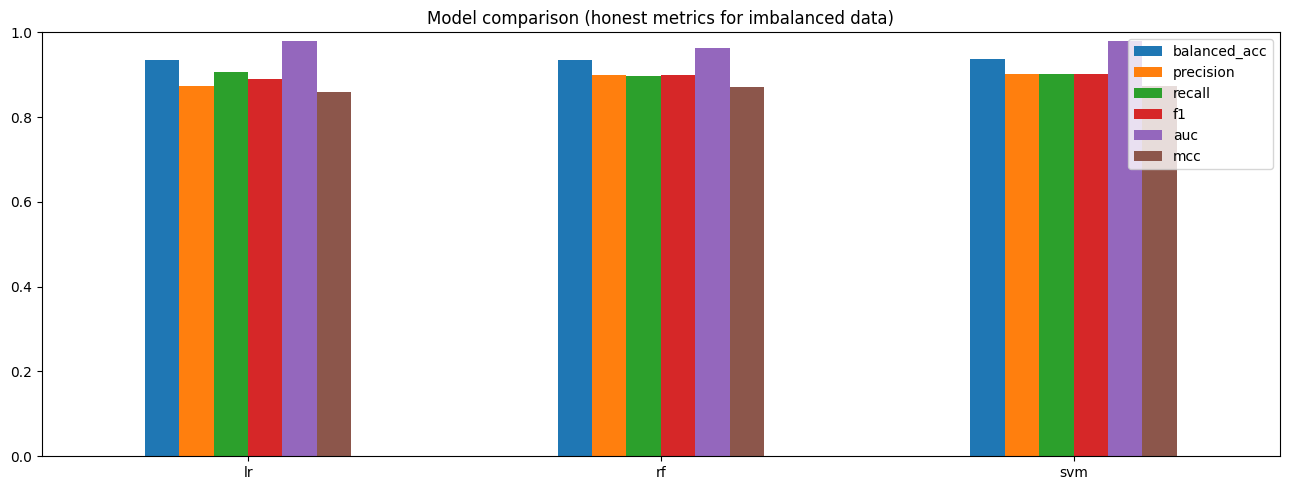

In [22]:
# Compare models — plot honest metrics
res = pd.DataFrame(results).T.round(4)
print(res)
res[["balanced_acc","precision","recall","f1","auc","mcc"]].plot(
    kind="bar", figsize=(13,5))
plt.title("Model comparison (honest metrics for imbalanced data)")
plt.ylim(0, 1); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


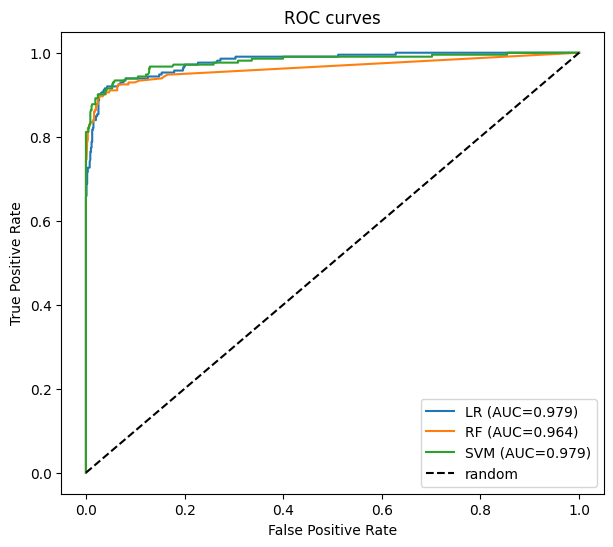

In [23]:
# 9.2 ROC curves
from sklearn.metrics import roc_curve
plt.figure(figsize=(7,6))
for name in ["lr","rf","svm"]:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    plt.plot(fpr, tpr, label=f"{name.upper()} (AUC={results[name]['auc']:.3f})")
plt.plot([0,1],[0,1], "k--", label="random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves"); plt.legend(); plt.show()


In [24]:
# Cross-validation (5-fold) on the FULL dataset
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_cv = feats.drop(columns=["label","is_attack"]).copy()
y_cv = feats["is_attack"].copy()
X_cv["method"] = X_cv["method"].astype(str)
X_cv["url"]    = X_cv["url"].fillna("")

cv = StratifiedKFold(5, shuffle=True, random_state=42)
for name in ["lr","rf","svm"]:
    pipe = build(name)
    bal_acc = cross_val_score(pipe, X_cv, y_cv, cv=cv,
                              scoring="balanced_accuracy", n_jobs=-1)
    f1  = cross_val_score(pipe, X_cv, y_cv, cv=cv,
                          scoring="f1", n_jobs=-1)
    mcc = cross_val_score(pipe, X_cv, y_cv, cv=cv,
                          scoring="matthews_corrcoef", n_jobs=-1)
    print(f"{name.upper():5s}: bal_acc={bal_acc.mean():.4f} (+-{bal_acc.std():.4f}), "
          f"f1={f1.mean():.4f} (+-{f1.std():.4f}), "
          f"mcc={mcc.mean():.4f} (+-{mcc.std():.4f})")


LR   : bal_acc=0.9415 (+-0.0046), f1=0.8878 (+-0.0123), mcc=0.8578 (+-0.0152)
RF   : bal_acc=0.9305 (+-0.0068), f1=0.8825 (+-0.0106), mcc=0.8509 (+-0.0135)
SVM  : bal_acc=0.9450 (+-0.0074), f1=0.9009 (+-0.0120), mcc=0.8742 (+-0.0155)


# 9.5 Multi-class view — per-attack-type precision / recall

In [25]:
# Per-attack-type precision/recall (multi-class view)
from sklearn.metrics import classification_report
y_mc = feats["label"]
X_mc = feats.drop(columns=["label","is_attack"]).copy()
X_mc["method"] = X_mc["method"].astype(str)
X_mc["url"] = X_mc["url"].fillna("")
Xtr, Xte, ytr, yte = train_test_split(X_mc, y_mc, test_size=0.2,
                                       stratify=y_mc, random_state=42, shuffle=True)
rf_mc = Pipeline([("pre", preproc),
                   ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                                  random_state=42, n_jobs=-1))])
rf_mc.fit(Xtr, ytr)
yp_mc = rf_mc.predict(Xte)
print(classification_report(yte, yp_mc, zero_division=0))


                       precision    recall  f1-score   support

               benign       0.97      0.96      0.96       788
 cross_site_scripting       1.00      1.00      1.00         6
             dir_scan       0.70      0.56      0.62        34
          dir_scan_go       0.16      0.21      0.18        34
      dir_scan_python       0.65      0.57      0.61        30
             rce_java       1.00      0.92      0.96        13
        rce_read_file       0.84      1.00      0.91        36
            rce_shell       0.00      0.00      0.00         2
          remote_code       0.94      1.00      0.97        31
sql_injection_attempt       0.67      0.77      0.71        26

             accuracy                           0.90      1000
            macro avg       0.69      0.70      0.69      1000
         weighted avg       0.91      0.90      0.90      1000



# 10. Conclusion & Reuse

In [26]:
# (Optional) Save the best model
#import joblib
#best = build("rf"); best.fit(X_train, y_train)
#joblib.dump(best, "best_model_rf.joblib")
#print("Saved best_model_rf.joblib")